# Route-3 7D Rescue Training and Development Selection

The production simulations and NPE training were executed by resumable scripts.
This notebook validates their manifests, displays all bounded candidates, and
documents the development-only primary-pipeline selection. It never opens the
fresh final outcomes.


In [1]:
from pathlib import Path
import json, os, sys
import numpy as np
import pandas as pd
from IPython.display import display, Image, Markdown

PROJECT_ROOT = Path.cwd().resolve()
while PROJECT_ROOT != PROJECT_ROOT.parent and not (PROJECT_ROOT / "S4_sbi").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
if not (PROJECT_ROOT / "S4_sbi").exists():
    raise RuntimeError("sleep_loop project root could not be resolved")
sys.path.insert(0, str(PROJECT_ROOT / "S4_sbi" / "src"))
RESULTS = PROJECT_ROOT / "S4_sbi" / "results" / "route3_7d_rescue"
print("CONDA_DEFAULT_ENV=", os.environ.get("CONDA_DEFAULT_ENV"))
print("sys.executable=", sys.executable)
print("sys.prefix=", sys.prefix)
print("PROJECT_ROOT=", PROJECT_ROOT)
assert "neurolib" in sys.executable.lower()


CONDA_DEFAULT_ENV= neurolib
sys.executable= C:\Users\YUS190\AppData\Local\anaconda3\envs\neurolib\python.exe
sys.prefix= C:\Users\YUS190\AppData\Local\anaconda3\envs\neurolib
PROJECT_ROOT= D:\Year3_Mao_Projects\sleep_loop


## Combined stochastic bank and group-safe split


In [2]:
from sleep_sbi.route3_7d_rescue import (
    BANK_ROOT, load_rescue_training_data, verify_rescue_preregistration,
)
verify_rescue_preregistration()
bank_manifest = json.loads((BANK_ROOT / "combined_bank_manifest.json").read_text())
display(pd.Series(bank_manifest, name="value").to_frame())
training_data = load_rescue_training_data()
assert bank_manifest["rows"] == 8192
assert bank_manifest["unique_theta_groups"] == 6144
assert bank_manifest["same_theta_cross_split_leakage"] is False


,value
created_utc,2026-07-28T02:49:55.421978+00:00
rows,8192
unique_theta_groups,6144
training_rows,6583
validation_rows,1609
training_groups,4915
validation_groups,1229
same_theta_cross_split_leakage,False
scaling_fit_on_training_only,True
bank_sha256,ec786169d1c03a3a908b4c1b7c0bfc891ab9174a198e35...


## Five-member ensembles

Both preregistered architectures use identical data, group split, optimizer
policy, and five independent initializations. Only hidden width/flow depth differ.


In [3]:
from sleep_sbi.route3_7d_rescue import TRAINING_ROOT, DEVELOPMENT_ROOT
training = []
for path in sorted(TRAINING_ROOT.glob("*/training_summary.csv")):
    frame = pd.read_csv(path)
    training.append(frame)
display(pd.concat(training, ignore_index=True).round(5))


,config_id,seed,device,status,epochs_completed,best_epoch,best_validation_loss,final_train_loss,runtime_this_call_s,checkpoint,checkpoint_sha256,rescue_preregistration_hash
0,maf128_t8,8932001,cpu,trained,189,188,-11.08711,-11.16518,271.51202,D:/Year3_Mao_Projects/sleep_loop/S4_sbi/result...,e0e3a4f728bedf2b9eced8b3bb117ae07b04f5c91a44e7...,01e0b0cb2277340872d95fef5fb5f2c0dd15bdf7104d36...
1,maf128_t8,8932002,cpu,trained,187,186,-10.72280,-11.14004,268.97160,D:/Year3_Mao_Projects/sleep_loop/S4_sbi/result...,d3dee6d4378e3f16da406768ae06a986452b10f01d95e7...,01e0b0cb2277340872d95fef5fb5f2c0dd15bdf7104d36...
2,maf128_t8,8932003,cpu,trained,213,212,-10.81559,-11.24649,303.77113,D:/Year3_Mao_Projects/sleep_loop/S4_sbi/result...,2389a80493293ed4ebd9e58e5d790030532b79b8cb3067...,01e0b0cb2277340872d95fef5fb5f2c0dd15bdf7104d36...
3,maf128_t8,8932004,cpu,trained,207,206,-11.04151,-11.30408,296.67276,D:/Year3_Mao_Projects/sleep_loop/S4_sbi/result...,37a71c0485724ad02d5c48d527887092e3ff49ef9a6122...,01e0b0cb2277340872d95fef5fb5f2c0dd15bdf7104d36...
4,maf128_t8,8932005,cpu,trained,177,176,-10.99210,-11.28302,252.32301,D:/Year3_Mao_Projects/sleep_loop/S4_sbi/result...,8570be5bb068ac0228f840bbdf7b6a7fc2da04cb8c25b8...,01e0b0cb2277340872d95fef5fb5f2c0dd15bdf7104d36...
5,maf64_t5,8931001,cpu,trained,295,294,-10.80024,-11.05809,168.50336,D:/Year3_Mao_Projects/sleep_loop/S4_sbi/result...,e05ba9d3354fc464edee2d992f24bc4c158b2f648d287a...,01e0b0cb2277340872d95fef5fb5f2c0dd15bdf7104d36...
6,maf64_t5,8931002,cpu,trained,285,284,-10.98678,-11.44196,170.32847,D:/Year3_Mao_Projects/sleep_loop/S4_sbi/result...,8180c78bbc31ba87f8944edb619816df6218790c87a476...,01e0b0cb2277340872d95fef5fb5f2c0dd15bdf7104d36...
7,maf64_t5,8931003,cpu,trained,299,298,-11.16998,-11.48530,174.04014,D:/Year3_Mao_Projects/sleep_loop/S4_sbi/result...,fb5fe4555d708ab74c41a252298582664096439b84c4de...,01e0b0cb2277340872d95fef5fb5f2c0dd15bdf7104d36...
8,maf64_t5,8931004,cpu,trained,294,293,-10.88842,-10.76356,169.87489,D:/Year3_Mao_Projects/sleep_loop/S4_sbi/result...,8d858318d33479afe83f0a964e51f01031ce96f3279946...,01e0b0cb2277340872d95fef5fb5f2c0dd15bdf7104d36...
9,maf64_t5,8931005,cpu,trained,293,292,-10.92016,-11.20941,170.62254,D:/Year3_Mao_Projects/sleep_loop/S4_sbi/result...,08caadcd3199d5ae29ee0d24eed329c6e38e8cfc355aab...,01e0b0cb2277340872d95fef5fb5f2c0dd15bdf7104d36...


## Development-only comparison and frozen selection


In [4]:
from sleep_sbi.route3_7d_rescue_training import verify_primary_pipeline_lock
selection = verify_primary_pipeline_lock()
candidates = pd.read_csv(DEVELOPMENT_ROOT / "candidate_pipeline_metrics.csv")
display(candidates.round(5))
display(pd.Series(selection, name="value").to_frame())


,config_id,method,formal_go_eligible,coverage_compatible_parameter_count,severe_undercoverage_parameter_count,contraction_with_coverage_parameter_count,aggregate_coverage_error,marginal_crps,overall_recovery_improvement_fraction,median_90_ci_width_mean,all_original_calibration_contraction_requirements
0,maf64_t5,raw,True,1,0,1,0.07731,0.08097,0.52937,0.40058,False
1,maf64_t5,empirical_rank_calibrated,False,7,0,7,0.00322,0.07989,0.53056,0.44813,True
2,maf128_t8,raw,True,1,0,1,0.08960,0.08113,0.52801,0.39989,False
3,maf128_t8,empirical_rank_calibrated,False,7,0,7,0.00182,0.08002,0.52932,0.45314,True


,value
created_utc,2026-07-28T03:31:09.921303+00:00
selected_config_id,maf128_t8
selected_method,empirical_rank_calibrated
formal_go_eligible,False
selection_metrics,"{'config_id': 'maf128_t8', 'method': 'empirica..."
selection_rule,[prefer a raw pipeline satisfying all unchange...
calibrator,{'method': 'marginal empirical-rank recalibrat...
rescue_preregistration_hash,01e0b0cb2277340872d95fef5fb5f2c0dd15bdf7104d36...
rescue_locked_sha256,01e0b0cb2277340872d95fef5fb5f2c0dd15bdf7104d36...


## Training and calibration evidence

Coverage error is evaluated only on the independent 512-case development set.
Rank recalibration, if selected, is monotone and preserves within-case marginal
ordering, but it is reported separately from raw SNPE.


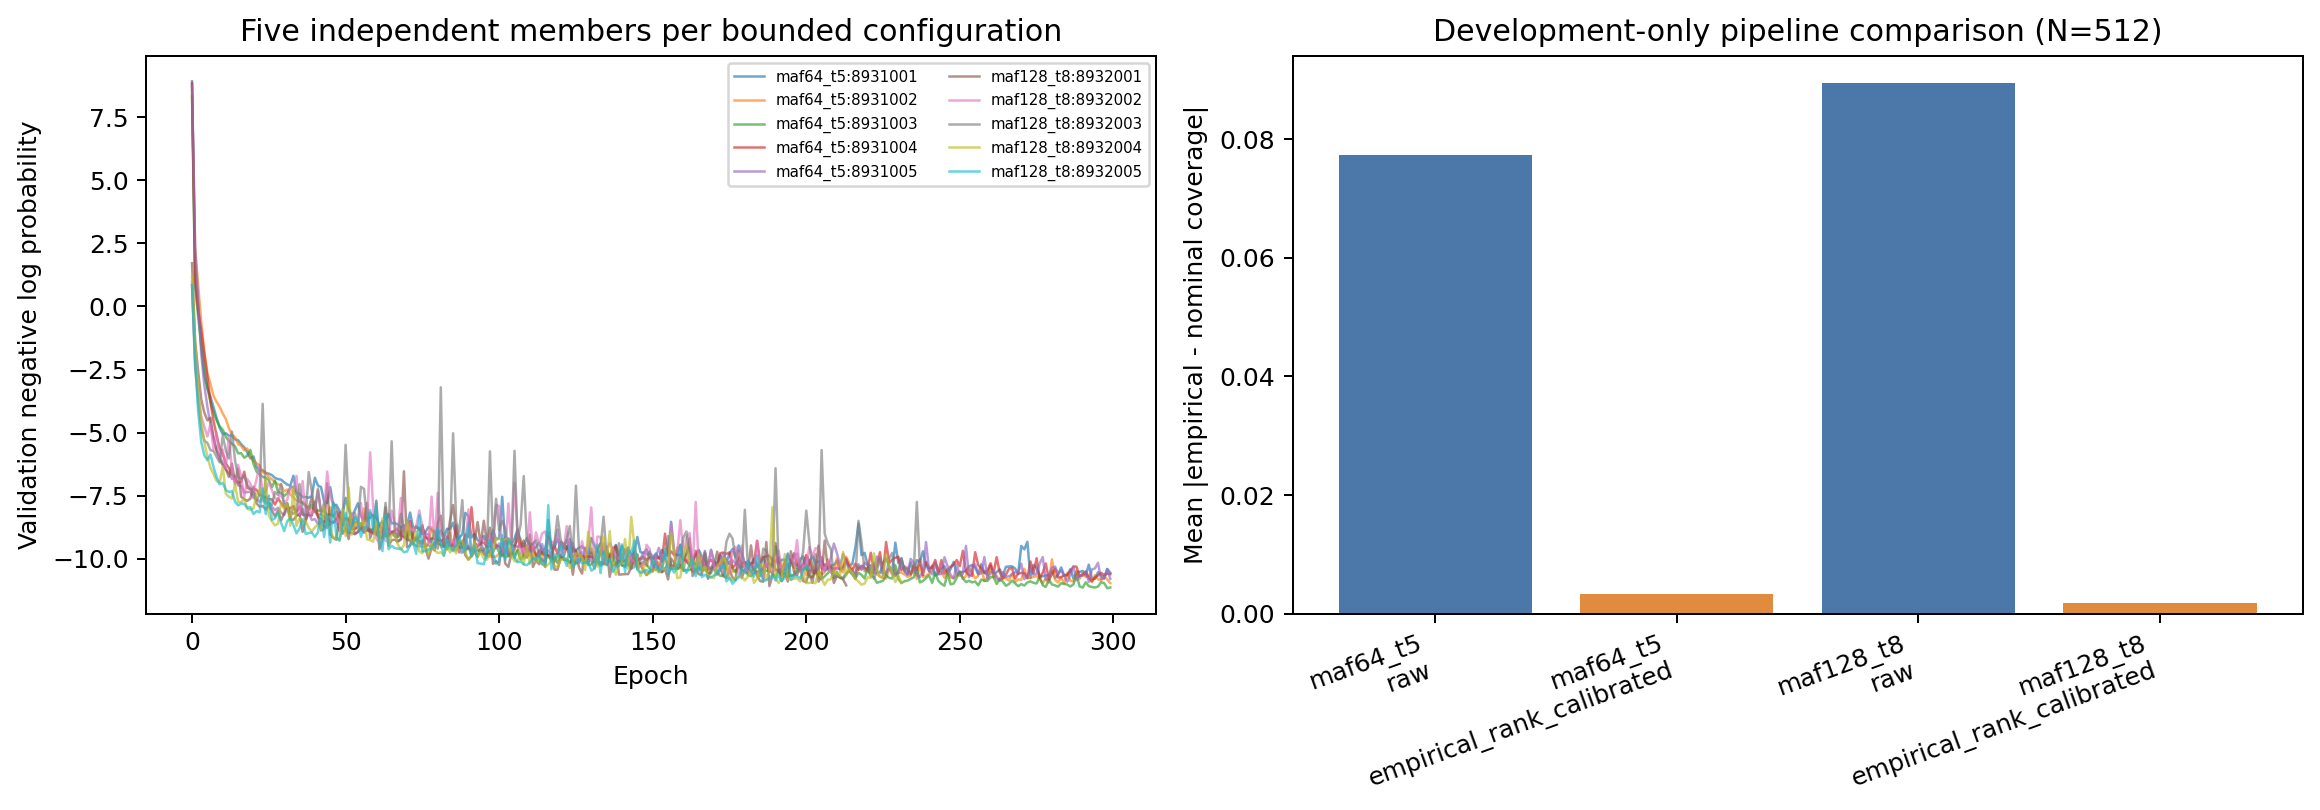

In [5]:
from sleep_sbi.route3_7d_rescue_reporting import plot_training_and_development
png, svg = plot_training_and_development()
display(Image(filename=str(png)))
